# Bio-PM IRB Analysis (Standard vs Adv)
Single regression notebook for Member 1 pipeline analysis.
Main task: LOSO regression predicting continuous ARAT/FMA from Bio-PM embeddings.


In [1]:
import sys, os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from collections import defaultdict
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.decomposition import PCA
import umap
warnings.filterwarnings('ignore')
%matplotlib inline

BIOPM_ROOT = "CS690TR"
sys.path.insert(0, BIOPM_ROOT)

STD_LEGACY = "features/biopm_features_legacy_schema.npz"
ADV_LEGACY = "features/biopm_features_legacy_schema_adv.npz"
ADV_WIN    = "features/biopm_features_adv.npz"
RESULTS    = "outputs"
os.makedirs(f"{RESULTS}/figures", exist_ok=True)
os.makedirs(f"{RESULTS}/metrics", exist_ok=True)
os.makedirs(f"{RESULTS}/splits", exist_ok=True)


## 1) Dataset Overview


Visits: 223
Subjects: 61
ARAT range: (np.float64(0.0), np.float64(57.0))
FMA range : (np.float64(3.0), np.float64(66.0))
Healthy visits convention (ARAT=57,FMA=66): 8
Healthy subjects: 8
Spearman ARAT~FMA: SignificanceResult(statistic=np.float64(0.9557208072313761), pvalue=np.float64(2.2039973243998045e-119))


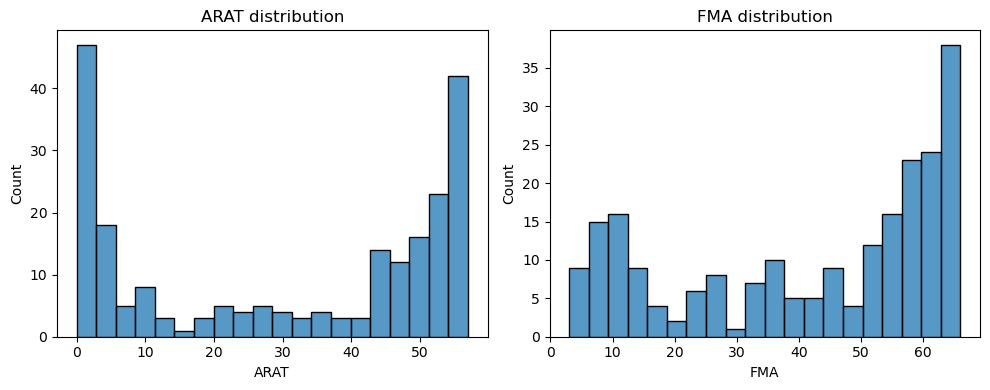

In [2]:
clin = np.load('data/clinical_scores.npz', allow_pickle=True)['clinical_scores'].item()
rows=[]
for (s,w),rec in clin.items():
    rows.append({'subject':int(s),'week':int(w),'ARAT':float(rec.ARAT),'FMA':float(rec.FMA)})
clin_df=pd.DataFrame(rows)
print('Visits:',len(clin_df))
print('Subjects:',clin_df.subject.nunique())
print('ARAT range:',(clin_df.ARAT.min(),clin_df.ARAT.max()))
print('FMA range :',(clin_df.FMA.min(),clin_df.FMA.max()))
healthy=(clin_df.ARAT==57)&(clin_df.FMA==66)
print('Healthy visits convention (ARAT=57,FMA=66):',int(healthy.sum()))
print('Healthy subjects:',clin_df.loc[healthy,'subject'].nunique())
print('Spearman ARAT~FMA:',spearmanr(clin_df.ARAT,clin_df.FMA))

fig,ax=plt.subplots(1,2,figsize=(10,4))
sns.histplot(clin_df.ARAT,bins=20,ax=ax[0],kde=False)
ax[0].set_title('ARAT distribution')
sns.histplot(clin_df.FMA,bins=20,ax=ax[1],kde=False)
ax[1].set_title('FMA distribution')
plt.tight_layout()
plt.show()


## 2) Load Features (Standard + Adv)


In [3]:
def load_legacy(path):
    d = np.load(path, allow_pickle=True)
    return {
        'X': np.ascontiguousarray(d['features'], dtype=np.float32),
        'Xe': np.ascontiguousarray(d['features_even'], dtype=np.float32),
        'Xo': np.ascontiguousarray(d['features_odd'], dtype=np.float32),
        'arat': d['arat'].astype(float),
        'fma': d['fma'].astype(float),
        'pids': d['pids'].astype(int),
        'labels': d['labels'].astype(int),
        'subjects': d['subjects'].astype(int),
        'weeks': d['weeks'].astype(int),
    }

def quality(name, X):
    print(f"{name}: shape={X.shape}, NaN={np.isnan(X).sum()}, zero_rows={(np.abs(X)<1e-8).all(axis=1).sum()}")
    print(f"  acc mean [0:64]  abs={np.abs(X[:,0:64]).mean():.5f}")
    print(f"  acc std  [64:128] abs={np.abs(X[:,64:128]).mean():.5f}")
    print(f"  grav     [128:]   abs={np.abs(X[:,128:]).mean():.5f}")

std = load_legacy(STD_LEGACY)
adv = load_legacy(ADV_LEGACY)
quality('Standard', std['X'])
quality('Adv', adv['X'])


Standard: shape=(198, 1028), NaN=0, zero_rows=0
  acc mean [0:64]  abs=0.68142
  acc std  [64:128] abs=0.41371
  grav     [128:]   abs=0.00196
Adv: shape=(198, 1028), NaN=0, zero_rows=0
  acc mean [0:64]  abs=0.73170
  acc std  [64:128] abs=0.36610
  grav     [128:]   abs=0.00485


## 3) LOSO Regression Helpers


In [4]:
def loso_regression(X, y_scores, pids, alpha=1.0, label=''):
    logo = LeaveOneGroupOut()
    y_true, y_pred = [], []
    for tr, te in logo.split(X, y_scores, groups=pids):
        X_tr, y_tr = X[tr], y_scores[tr]
        X_te, y_te = X[te], y_scores[te]
        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_te_s = sc.transform(X_te)
        reg = Ridge(alpha=alpha)
        reg.fit(X_tr_s, y_tr)
        y_pred.extend(reg.predict(X_te_s).tolist())
        y_true.extend(y_te.tolist())
    y_true=np.array(y_true); y_pred=np.array(y_pred)
    ss_res=((y_true-y_pred)**2).sum(); ss_tot=((y_true-y_true.mean())**2).sum()
    r2=1-ss_res/ss_tot
    rmse=np.sqrt(((y_true-y_pred)**2).mean())
    sr,sp=spearmanr(y_true,y_pred)
    print(f"{label}: R²={r2:.3f} RMSE={rmse:.2f} Spearman ρ={sr:.3f} (p={sp:.3g})")
    return {'r2':r2,'rmse':rmse,'spearman_r':sr,'spearman_p':sp,'y_true':y_true,'y_pred':y_pred}

def loso_regression_pca(X, y_scores, pids, n_components=50, alpha=1.0, label=''):
    logo = LeaveOneGroupOut()
    y_true, y_pred = [], []
    for tr, te in logo.split(X, y_scores, groups=pids):
        X_tr, y_tr = X[tr], y_scores[tr]
        X_te, y_te = X[te], y_scores[te]
        sc=StandardScaler(); X_tr_s=sc.fit_transform(X_tr); X_te_s=sc.transform(X_te)
        pca=PCA(n_components=min(n_components, X_tr_s.shape[0]-1, X_tr_s.shape[1]))
        X_tr_p=pca.fit_transform(X_tr_s); X_te_p=pca.transform(X_te_s)
        reg=Ridge(alpha=alpha); reg.fit(X_tr_p,y_tr)
        y_pred.extend(reg.predict(X_te_p).tolist()); y_true.extend(y_te.tolist())
    y_true=np.array(y_true); y_pred=np.array(y_pred)
    ss_res=((y_true-y_pred)**2).sum(); ss_tot=((y_true-y_true.mean())**2).sum()
    r2=1-ss_res/ss_tot; rmse=np.sqrt(((y_true-y_pred)**2).mean()); sr,sp=spearmanr(y_true,y_pred)
    print(f"{label} [PCA]: R²={r2:.3f} RMSE={rmse:.2f} Spearman ρ={sr:.3f} (p={sp:.3g})")
    return {'r2':r2,'rmse':rmse,'spearman_r':sr,'spearman_p':sp,'y_true':y_true,'y_pred':y_pred}

def plot_pred(ax, y_true, y_pred, title):
    ax.scatter(y_true,y_pred,s=30,alpha=0.8)
    lo=min(y_true.min(),y_pred.min()); hi=max(y_true.max(),y_pred.max())
    ax.plot([lo,hi],[lo,hi],'r--',lw=1)
    ax.set_title(title); ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')


## 4) Standard Pipeline Regression


Standard -> ARAT: R²=0.556 RMSE=15.36 Spearman ρ=0.742 (p=7.06e-36)
Standard -> FMA: R²=0.400 RMSE=16.55 Spearman ρ=0.688 (p=4.34e-29)
Standard -> ARAT [PCA]: R²=0.582 RMSE=14.90 Spearman ρ=0.756 (p=7.55e-38)
Standard -> FMA [PCA]: R²=0.447 RMSE=15.90 Spearman ρ=0.716 (p=1.78e-32)


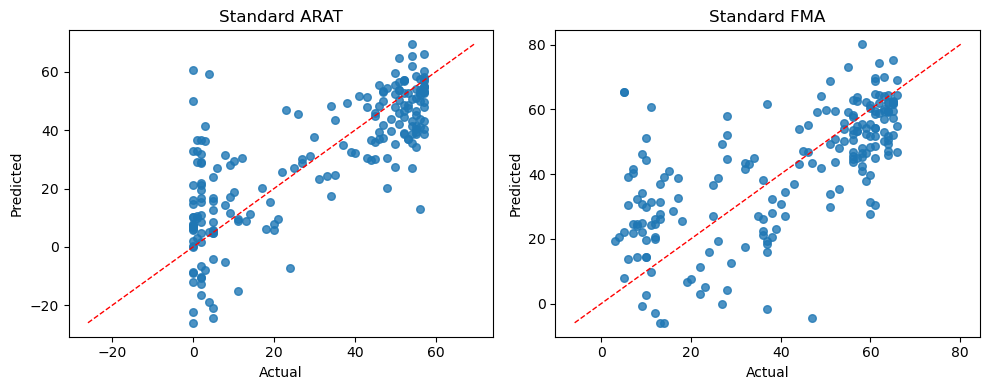

In [5]:
res_std_arat = loso_regression(std['X'], std['arat'], std['pids'], label='Standard -> ARAT')
res_std_fma  = loso_regression(std['X'], std['fma'],  std['pids'], label='Standard -> FMA')
res_std_arat_pca = loso_regression_pca(std['X'], std['arat'], std['pids'], label='Standard -> ARAT')
res_std_fma_pca  = loso_regression_pca(std['X'], std['fma'],  std['pids'], label='Standard -> FMA')

fig,ax=plt.subplots(1,2,figsize=(10,4))
plot_pred(ax[0],res_std_arat['y_true'],res_std_arat['y_pred'],'Standard ARAT')
plot_pred(ax[1],res_std_fma['y_true'],res_std_fma['y_pred'],'Standard FMA')
plt.tight_layout(); plt.savefig('outputs/figures/regression_standard.png',dpi=150); plt.show()

pd.DataFrame([
    {'target':'ARAT','pipeline':'Standard','r2':res_std_arat['r2'],'rmse':res_std_arat['rmse'],'spearman_r':res_std_arat['spearman_r']},
    {'target':'FMA','pipeline':'Standard','r2':res_std_fma['r2'],'rmse':res_std_fma['rmse'],'spearman_r':res_std_fma['spearman_r']},
]).to_csv('outputs/metrics/regression_standard.csv',index=False)


## 5) Adv Pipeline Regression


Adv -> ARAT: R²=-1.057 RMSE=33.05 Spearman ρ=0.436 (p=1.34e-10)
Adv -> FMA: R²=-1.408 RMSE=33.16 Spearman ρ=0.356 (p=2.65e-07)
Adv -> ARAT [PCA]: R²=0.414 RMSE=17.63 Spearman ρ=0.677 (p=6.6e-28)
Adv -> FMA [PCA]: R²=0.306 RMSE=17.81 Spearman ρ=0.643 (p=1.79e-24)


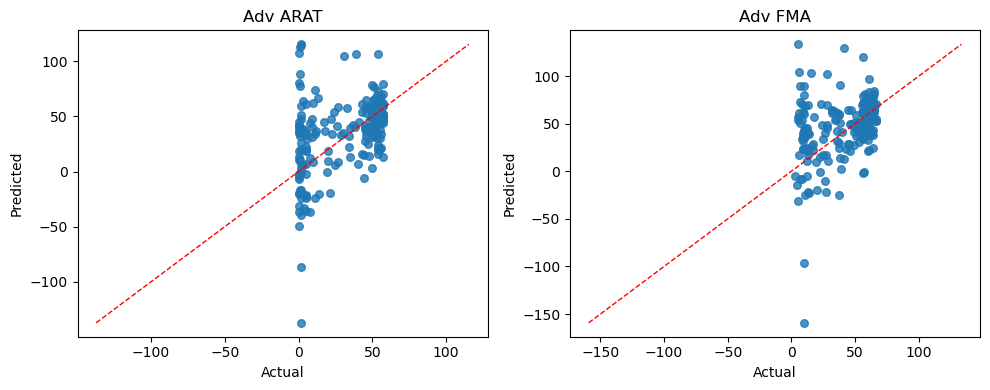

In [6]:
res_adv_arat = loso_regression(adv['X'], adv['arat'], adv['pids'], label='Adv -> ARAT')
res_adv_fma  = loso_regression(adv['X'], adv['fma'],  adv['pids'], label='Adv -> FMA')
res_adv_arat_pca = loso_regression_pca(adv['X'], adv['arat'], adv['pids'], label='Adv -> ARAT')
res_adv_fma_pca  = loso_regression_pca(adv['X'], adv['fma'],  adv['pids'], label='Adv -> FMA')

fig,ax=plt.subplots(1,2,figsize=(10,4))
plot_pred(ax[0],res_adv_arat['y_true'],res_adv_arat['y_pred'],'Adv ARAT')
plot_pred(ax[1],res_adv_fma['y_true'],res_adv_fma['y_pred'],'Adv FMA')
plt.tight_layout(); plt.savefig('outputs/figures/regression_adv.png',dpi=150); plt.show()

pd.DataFrame([
    {'target':'ARAT','pipeline':'Adv','r2':res_adv_arat['r2'],'rmse':res_adv_arat['rmse'],'spearman_r':res_adv_arat['spearman_r']},
    {'target':'FMA','pipeline':'Adv','r2':res_adv_fma['r2'],'rmse':res_adv_fma['rmse'],'spearman_r':res_adv_fma['spearman_r']},
]).to_csv('outputs/metrics/regression_adv.csv',index=False)


## 6) Standard vs Adv Comparison


,target,pipeline,r2,rmse,spearman_r
0,ARAT,Standard,0.555734,15.358734,0.741969
1,ARAT,Adv,-1.057455,33.052096,0.436128
2,FMA,Standard,0.399898,16.554977,0.687886
3,FMA,Adv,-1.407827,33.161095,0.355977


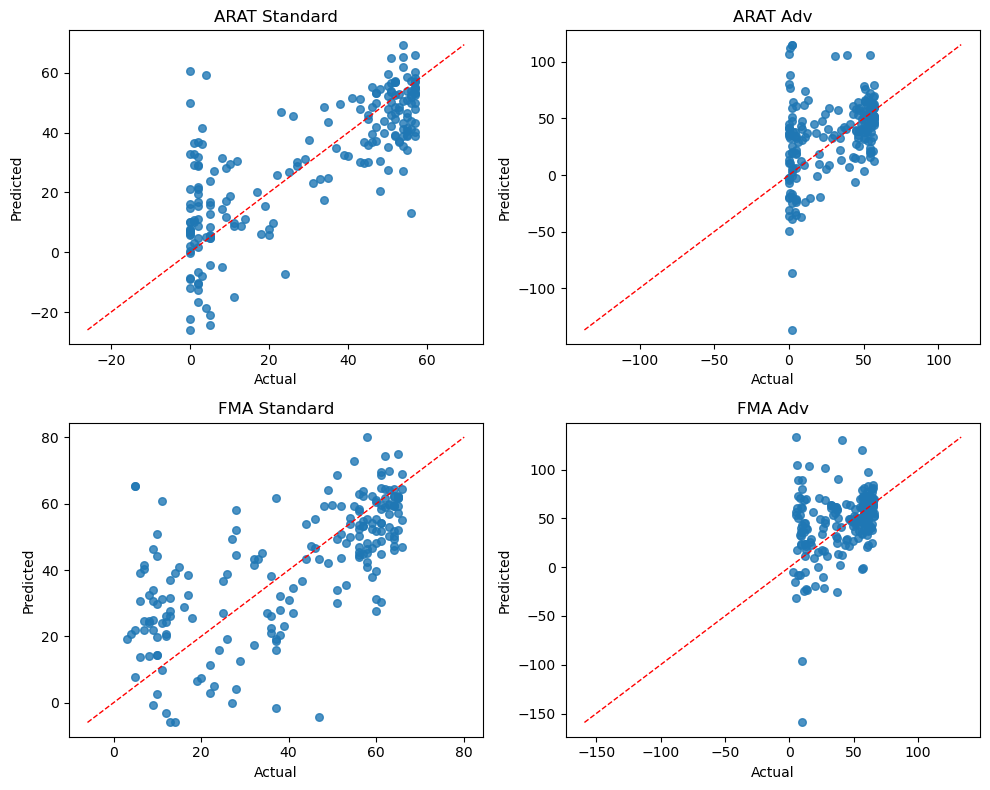

In [7]:
comp = pd.DataFrame([
    {'target':'ARAT','pipeline':'Standard','r2':res_std_arat['r2'],'rmse':res_std_arat['rmse'],'spearman_r':res_std_arat['spearman_r']},
    {'target':'ARAT','pipeline':'Adv','r2':res_adv_arat['r2'],'rmse':res_adv_arat['rmse'],'spearman_r':res_adv_arat['spearman_r']},
    {'target':'FMA','pipeline':'Standard','r2':res_std_fma['r2'],'rmse':res_std_fma['rmse'],'spearman_r':res_std_fma['spearman_r']},
    {'target':'FMA','pipeline':'Adv','r2':res_adv_fma['r2'],'rmse':res_adv_fma['rmse'],'spearman_r':res_adv_fma['spearman_r']},
])
comp.to_csv('outputs/metrics/regression_comparison.csv',index=False)
display(comp)

fig,ax=plt.subplots(2,2,figsize=(10,8))
plot_pred(ax[0,0],res_std_arat['y_true'],res_std_arat['y_pred'],'ARAT Standard')
plot_pred(ax[0,1],res_adv_arat['y_true'],res_adv_arat['y_pred'],'ARAT Adv')
plot_pred(ax[1,0],res_std_fma['y_true'],res_std_fma['y_pred'],'FMA Standard')
plot_pred(ax[1,1],res_adv_fma['y_true'],res_adv_fma['y_pred'],'FMA Adv')
plt.tight_layout(); plt.savefig('outputs/figures/regression_comparison.png',dpi=150); plt.show()


## 7) Aggregation Experiments (Adv)


full_1028 -> ARAT: R²=-1.057 RMSE=33.05 Spearman ρ=0.436 (p=1.34e-10)
full_1028 -> FMA: R²=-1.408 RMSE=33.16 Spearman ρ=0.356 (p=2.65e-07)
acc_128 -> ARAT: R²=0.513 RMSE=16.08 Spearman ρ=0.721 (p=5.16e-33)
acc_128 -> FMA: R²=0.401 RMSE=16.54 Spearman ρ=0.687 (p=5.11e-29)
acc_meanpool_64 -> ARAT: R²=0.569 RMSE=15.14 Spearman ρ=0.751 (p=3.37e-37)
acc_meanpool_64 -> FMA: R²=0.491 RMSE=15.24 Spearman ρ=0.728 (p=5.99e-34)
acc_stdpool_64 -> ARAT: R²=0.456 RMSE=16.99 Spearman ρ=0.705 (p=4.22e-31)
acc_stdpool_64 -> FMA: R²=0.355 RMSE=17.16 Spearman ρ=0.673 (p=1.87e-27)
gravity_900 -> ARAT: R²=-5.053 RMSE=56.69 Spearman ρ=-0.080 (p=0.262)
gravity_900 -> FMA: R²=-5.868 RMSE=56.01 Spearman ρ=-0.112 (p=0.115)
agg=mean -> ARAT: R²=-1.057 RMSE=33.05 Spearman ρ=0.436 (p=1.34e-10)
agg=mean -> FMA: R²=-1.408 RMSE=33.16 Spearman ρ=0.356 (p=2.65e-07)
agg=max -> ARAT: R²=0.449 RMSE=17.10 Spearman ρ=0.762 (p=7.16e-39)
agg=max -> FMA: R²=0.268 RMSE=18.28 Spearman ρ=0.697 (p=4.41e-30)
agg=mean_std_max -> ARA

,experiment,mode,target,r2,rmse,spearman_r
0,dim_group,full_1028,ARAT,-1.057455,33.052096,0.436128
1,dim_group,full_1028,FMA,-1.407827,33.161095,0.355977
2,dim_group,acc_128,ARAT,0.513254,16.076253,0.720677
3,dim_group,acc_128,FMA,0.401006,16.539694,0.687255
4,dim_group,acc_meanpool_64,ARAT,0.568527,15.135987,0.751136
5,dim_group,acc_meanpool_64,FMA,0.491150,15.244431,0.727852
6,dim_group,acc_stdpool_64,ARAT,0.456287,16.990982,0.705260
7,dim_group,acc_stdpool_64,FMA,0.355374,17.158133,0.672822
8,dim_group,gravity_900,ARAT,-5.052830,56.690860,-0.080098
9,dim_group,gravity_900,FMA,-5.868334,56.006947,-0.112442


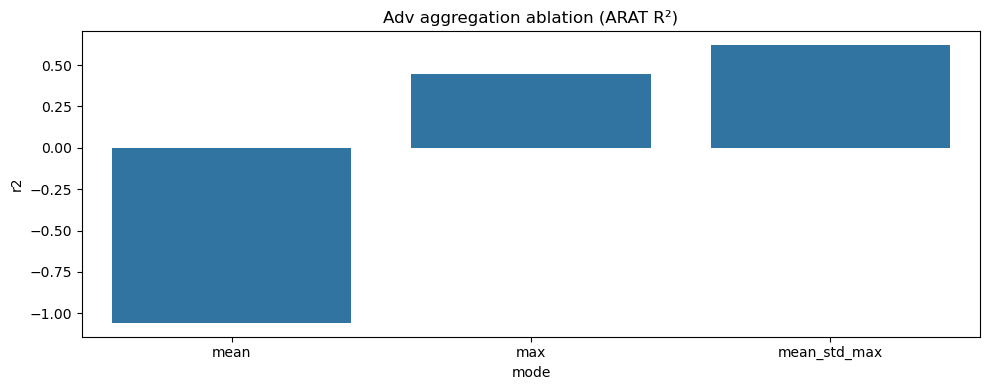

In [8]:
dim_groups={
    'full_1028':(0,1028),
    'acc_128':(0,128),
    'acc_meanpool_64':(0,64),
    'acc_stdpool_64':(64,128),
    'gravity_900':(128,1028),
}
rows=[]
for name,(a,b) in dim_groups.items():
    rA=loso_regression(adv['X'][:,a:b],adv['arat'],adv['pids'],label=f'{name} -> ARAT')
    rF=loso_regression(adv['X'][:,a:b],adv['fma'],adv['pids'],label=f'{name} -> FMA')
    rows += [
        {'experiment':'dim_group','mode':name,'target':'ARAT','r2':rA['r2'],'rmse':rA['rmse'],'spearman_r':rA['spearman_r']},
        {'experiment':'dim_group','mode':name,'target':'FMA','r2':rF['r2'],'rmse':rF['rmse'],'spearman_r':rF['spearman_r']},
    ]

adv_win=np.load(ADV_WIN,allow_pickle=True)
Xw=adv_win['features'].astype(np.float32); sw=adv_win['subj'].astype(int); ww=adv_win['week'].astype(int)

def aggregate_windows(features_win, subj, week, mode='mean'):
    groups=defaultdict(list)
    for i,(s,w) in enumerate(zip(subj,week)):
        groups[(s,w)].append(i)
    out=[]
    for key in sorted(groups.keys()):
        idx=np.array(groups[key]); blk=features_win[idx]
        if mode=='mean': out.append(blk.mean(0))
        elif mode=='max': out.append(blk.max(0))
        elif mode=='mean_std_max': out.append(np.concatenate([blk.mean(0),blk.std(0),blk.max(0)]))
    return np.array(out)

# align targets by (subject,week)
key_to_idx={(int(s),int(w)):i for i,(s,w) in enumerate(zip(adv['subjects'],adv['weeks']))}
visit_keys=sorted(set(zip(sw,ww)))
y_arat=np.array([adv['arat'][key_to_idx[k]] for k in visit_keys])
y_fma=np.array([adv['fma'][key_to_idx[k]] for k in visit_keys])
y_pids=np.array([k[0] for k in visit_keys])

for mode in ['mean','max','mean_std_max']:
    Xa=aggregate_windows(Xw,sw,ww,mode=mode)
    rA=loso_regression(Xa,y_arat,y_pids,label=f'agg={mode} -> ARAT')
    rF=loso_regression(Xa,y_fma,y_pids,label=f'agg={mode} -> FMA')
    rows += [
        {'experiment':'window_agg','mode':mode,'target':'ARAT','r2':rA['r2'],'rmse':rA['rmse'],'spearman_r':rA['spearman_r']},
        {'experiment':'window_agg','mode':mode,'target':'FMA','r2':rF['r2'],'rmse':rF['rmse'],'spearman_r':rF['spearman_r']},
    ]

agg_df=pd.DataFrame(rows)
agg_df.to_csv('outputs/metrics/aggregation_ablation.csv',index=False)
display(agg_df.head(20))

fig,ax=plt.subplots(figsize=(10,4))
plot_df=agg_df[(agg_df['experiment']=='window_agg') & (agg_df['target']=='ARAT')]
sns.barplot(data=plot_df,x='mode',y='r2',ax=ax)
ax.set_title('Adv aggregation ablation (ARAT R²)')
plt.tight_layout(); plt.savefig('outputs/figures/aggregation_ablation.png',dpi=150); plt.show()


## 8) Spearman Correlation Profiles


Top-10 |rho| ARAT (Adv): [(np.int64(94), np.float64(0.7585398827490416)), (np.int64(66), np.float64(0.7407642780017455)), (np.int64(82), np.float64(0.720406382805687)), (np.int64(68), np.float64(0.7145999072208993)), (np.int64(116), np.float64(0.7015723099793929)), (np.int64(90), np.float64(0.6972261641656292)), (np.int64(107), np.float64(0.6909403968903515)), (np.int64(11), np.float64(-0.689370116521509)), (np.int64(27), np.float64(-0.6892965580229686)), (np.int64(47), np.float64(-0.6817858481719962))]
Top-10 |rho| FMA  (Adv): [(np.int64(94), np.float64(0.7437958789262906)), (np.int64(66), np.float64(0.719924852515117)), (np.int64(68), np.float64(0.7057176206429016)), (np.int64(82), np.float64(0.7049620566812689)), (np.int64(116), np.float64(0.6936115835339985)), (np.int64(27), np.float64(-0.6865586220907126)), (np.int64(11), np.float64(-0.6863374436945746)), (np.int64(5), np.float64(0.6767169568136013)), (np.int64(23), np.float64(-0.6765947673500006)), (np.int64(107), np.float64(0.67

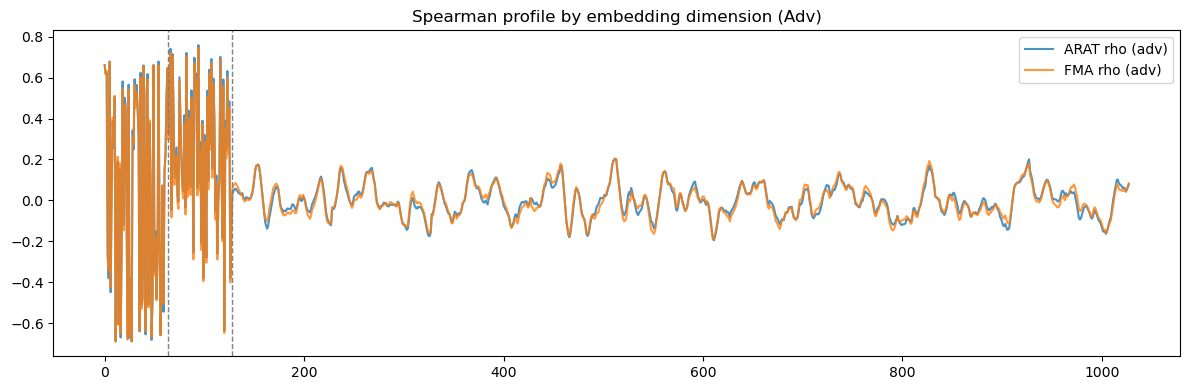

In [9]:
def spearman_profile(X, arat, fma):
    sA=np.zeros(X.shape[1]); sF=np.zeros(X.shape[1])
    for d in range(X.shape[1]):
        sA[d],_=spearmanr(X[:,d],arat)
        sF[d],_=spearmanr(X[:,d],fma)
    return sA,sF

sA_adv,sF_adv=spearman_profile(adv['X'],adv['arat'],adv['fma'])
sA_std,sF_std=spearman_profile(std['X'],std['arat'],std['fma'])

pd.DataFrame({'dim':np.arange(1028),'rho_arat':sA_adv,'rho_fma':sF_adv}).to_csv('outputs/metrics/spearman_adv.csv',index=False)
pd.DataFrame({'dim':np.arange(1028),'rho_arat':sA_std,'rho_fma':sF_std}).to_csv('outputs/metrics/spearman_standard.csv',index=False)

def topk(rho,k=10):
    idx=np.argsort(np.abs(rho))[::-1][:k]
    return list(zip(idx,rho[idx]))

print('Top-10 |rho| ARAT (Adv):',topk(sA_adv,10))
print('Top-10 |rho| FMA  (Adv):',topk(sF_adv,10))

fig,ax=plt.subplots(figsize=(12,4))
ax.plot(sA_adv,label='ARAT rho (adv)',alpha=0.8)
ax.plot(sF_adv,label='FMA rho (adv)',alpha=0.8)
ax.axvline(64,color='gray',ls='--',lw=1); ax.axvline(128,color='gray',ls='--',lw=1)
ax.set_title('Spearman profile by embedding dimension (Adv)')
ax.legend(); plt.tight_layout(); plt.savefig('outputs/figures/spearman_profile.png',dpi=150); plt.show()


## 9) ICC Reliability (Even vs Odd)


Adv ICC >0.75: 128 /1028
Adv ICC 0.5-0.75: 5 /1028
Adv ICC <=0.5: 895 /1028


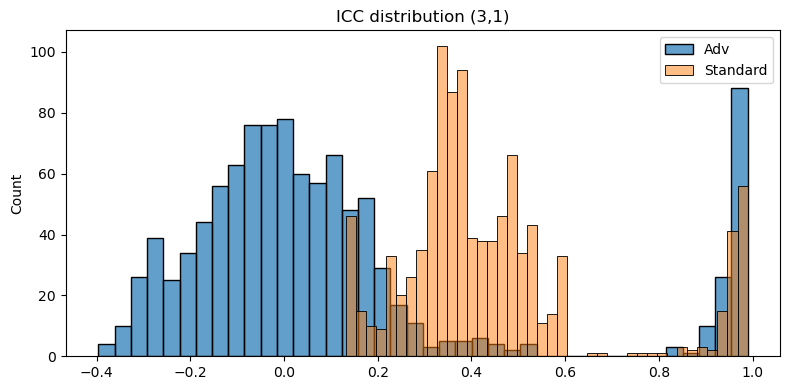

In [10]:
def icc_3_1(x,y):
    n=len(x)
    m=(x+y)/2.0
    SS_between=2*n*m.var()
    SS_within=((x-m)**2 + (y-m)**2).sum()
    MS_between=SS_between/(n-1)
    MS_within=SS_within/n
    return (MS_between-MS_within)/(MS_between+MS_within)

def icc_profile(Xe,Xo):
    out=np.zeros(Xe.shape[1])
    for d in range(Xe.shape[1]):
        out[d]=icc_3_1(Xe[:,d],Xo[:,d])
    return out

icc_adv=icc_profile(adv['Xe'],adv['Xo'])
icc_std=icc_profile(std['Xe'],std['Xo'])

pd.DataFrame({'dim':np.arange(1028),'icc':icc_adv}).to_csv('outputs/metrics/icc_adv.csv',index=False)
pd.DataFrame({'dim':np.arange(1028),'icc':icc_std}).to_csv('outputs/metrics/icc_standard.csv',index=False)

print('Adv ICC >0.75:',int((icc_adv>0.75).sum()),'/1028')
print('Adv ICC 0.5-0.75:',int(((icc_adv>0.5)&(icc_adv<=0.75)).sum()),'/1028')
print('Adv ICC <=0.5:',int((icc_adv<=0.5).sum()),'/1028')

fig,ax=plt.subplots(figsize=(8,4))
sns.histplot(icc_adv,bins=40,ax=ax,color='tab:blue',alpha=0.7,label='Adv')
sns.histplot(icc_std,bins=40,ax=ax,color='tab:orange',alpha=0.5,label='Standard')
ax.legend(); ax.set_title('ICC distribution (3,1)');
plt.tight_layout(); plt.savefig('outputs/figures/icc_distribution.png',dpi=150); plt.show()


## 10) Summary + Full Metrics Export


In [11]:
summary_rows=[
    {'section':'dataset','metric':'subjects_total','value':int(clin_df.subject.nunique())},
    {'section':'dataset','metric':'visits_total','value':int(len(clin_df))},
    {'section':'dataset','metric':'healthy_visits','value':int(((clin_df.ARAT==57)&(clin_df.FMA==66)).sum())},
    {'section':'regression','metric':'ARAT_R2_standard','value':res_std_arat['r2']},
    {'section':'regression','metric':'ARAT_R2_adv','value':res_adv_arat['r2']},
    {'section':'regression','metric':'FMA_R2_standard','value':res_std_fma['r2']},
    {'section':'regression','metric':'FMA_R2_adv','value':res_adv_fma['r2']},
    {'section':'regression','metric':'ARAT_spearman_standard','value':res_std_arat['spearman_r']},
    {'section':'regression','metric':'ARAT_spearman_adv','value':res_adv_arat['spearman_r']},
    {'section':'regression','metric':'FMA_spearman_standard','value':res_std_fma['spearman_r']},
    {'section':'regression','metric':'FMA_spearman_adv','value':res_adv_fma['spearman_r']},
    {'section':'icc_adv','metric':'count_gt_0_75','value':int((icc_adv>0.75).sum())},
    {'section':'icc_adv','metric':'count_gt_0_50','value':int((icc_adv>0.50).sum())},
]
summary_df=pd.DataFrame(summary_rows)
summary_df.to_csv('outputs/metrics/full_summary.csv',index=False)
display(summary_df)


,section,metric,value
0,dataset,subjects_total,61.000000
1,dataset,visits_total,223.000000
2,dataset,healthy_visits,8.000000
3,regression,ARAT_R2_standard,0.555734
4,regression,ARAT_R2_adv,-1.057455
5,regression,FMA_R2_standard,0.399898
6,regression,FMA_R2_adv,-1.407827
7,regression,ARAT_spearman_standard,0.741969
8,regression,ARAT_spearman_adv,0.436128
9,regression,FMA_spearman_standard,0.687886
